In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Plant 1
p1_gen = pd.read_csv('../data/raw/solar/Plant_1_Generation_Data.csv')
p1_weather = pd.read_csv('../data/raw/solar/Plant_1_Weather_Sensor_Data.csv')

# Load Plant 2
p2_gen = pd.read_csv('../data/raw/solar/Plant_2_Generation_Data.csv')
p2_weather = pd.read_csv('../data/raw/solar/Plant_2_Weather_Sensor_Data.csv')

print(p1_gen.shape, p1_weather.shape, p2_gen.shape, p2_weather.shape)
print(p1_gen.columns.tolist())
print(p1_weather.columns.tolist())

(68778, 7) (3182, 6) (67698, 7) (3259, 6)
['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']
['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']


In [2]:
# Parse datetime columns
p1_gen['DATE_TIME'] = pd.to_datetime(p1_gen['DATE_TIME'], dayfirst=True)
p1_weather['DATE_TIME'] = pd.to_datetime(p1_weather['DATE_TIME'], dayfirst=True)
p2_gen['DATE_TIME'] = pd.to_datetime(p2_gen['DATE_TIME'], dayfirst=True)
p2_weather['DATE_TIME'] = pd.to_datetime(p2_weather['DATE_TIME'], dayfirst=True)

# Merge generation + weather for each plant on DATE_TIME
plant1 = pd.merge(p1_gen, p1_weather, on='DATE_TIME', suffixes=('_gen', '_weather'))
plant2 = pd.merge(p2_gen, p2_weather, on='DATE_TIME', suffixes=('_gen', '_weather'))

# Tag which plant, then combine into one dataframe
plant1['PLANT'] = 'Plant_1'
plant2['PLANT'] = 'Plant_2'
solar_df = pd.concat([plant1, plant2], ignore_index=True)

print(solar_df.shape)
solar_df.head()

(136472, 13)


C:\Users\JH\AppData\Local\Temp\ipykernel_15500\247972054.py:3: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  p1_weather['DATE_TIME'] = pd.to_datetime(p1_weather['DATE_TIME'], dayfirst=True)
C:\Users\JH\AppData\Local\Temp\ipykernel_15500\247972054.py:4: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  p2_gen['DATE_TIME'] = pd.to_datetime(p2_gen['DATE_TIME'], dayfirst=True)
C:\Users\JH\AppData\Local\Temp\ipykernel_15500\247972054.py:5: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  p2_weather['DATE_TIME'] = pd.to_datetime(p2_weather['DATE_TIME'], dayfirst=True)


,DATE_TIME,PLANT_ID_gen,SOURCE_KEY_gen,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_weather,SOURCE_KEY_weather,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,PLANT
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,Plant_1
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,Plant_1
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,Plant_1
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,Plant_1
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,Plant_1


## Data Overview
Checking data types, row counts, and missing values for the merged solar dataset (Plant 1 + Plant 2, generation + weather combined).

In [6]:
solar_df.info()  # .info() shows column data types and non-null counts — quick check that DATE_TIME
                #parsed correctly as a datetime and that no columns unexpectedly have missing values
solar_df.isnull().sum()  # isnull().sum() gives an explicit count of missing values per column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136472 entries, 0 to 136471
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   DATE_TIME            136472 non-null  datetime64[ns]
 1   PLANT_ID_gen         136472 non-null  int64         
 2   SOURCE_KEY_gen       136472 non-null  object        
 3   DC_POWER             136472 non-null  float64       
 4   AC_POWER             136472 non-null  float64       
 5   DAILY_YIELD          136472 non-null  float64       
 6   TOTAL_YIELD          136472 non-null  float64       
 7   PLANT_ID_weather     136472 non-null  int64         
 8   SOURCE_KEY_weather   136472 non-null  object        
 9   AMBIENT_TEMPERATURE  136472 non-null  float64       
 10  MODULE_TEMPERATURE   136472 non-null  float64       
 11  IRRADIATION          136472 non-null  float64       
 12  PLANT                136472 non-null  object        
dtypes: datetime64[

DATE_TIME              0
PLANT_ID_gen           0
SOURCE_KEY_gen         0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
PLANT_ID_weather       0
SOURCE_KEY_weather     0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
PLANT                  0
dtype: int64

## Summary Statistics
Checking the numeric ranges of power output and weather readings — looking for anything physically implausible (e.g. negative power, out-of-range irradiation).

In [7]:
solar_df[['DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']].describe()
# describe() gives min/max/mean/percentiles — used here to sanity-check that
# power values aren't negative and irradiation/temperature fall in expected ranges

,DC_POWER,AC_POWER,DAILY_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,136472.000000,136472.000000,136472.000000,136472.000000,136472.000000,136472.000000
mean,1708.373962,274.790259,3295.366192,26.763066,31.920744,0.230767
std,3222.079306,380.180214,3035.313217,3.897340,11.803674,0.305652
min,0.000000,0.000000,0.000000,20.398505,18.140415,0.000000
25%,0.000000,0.000000,28.285714,23.637604,22.411698,0.000000
50%,5.993333,3.493095,2834.642857,25.908122,26.413755,0.026213
75%,1155.595000,532.568571,5992.000000,29.266583,40.778583,0.442961
max,14471.125000,1410.950000,9873.000000,39.181638,66.635953,1.221652


## Daily Generation Pattern
Plotting AC power output over time for a single inverter to visually confirm the expected solar cycle — power should rise during daylight hours and drop to zero at night, repeating daily.

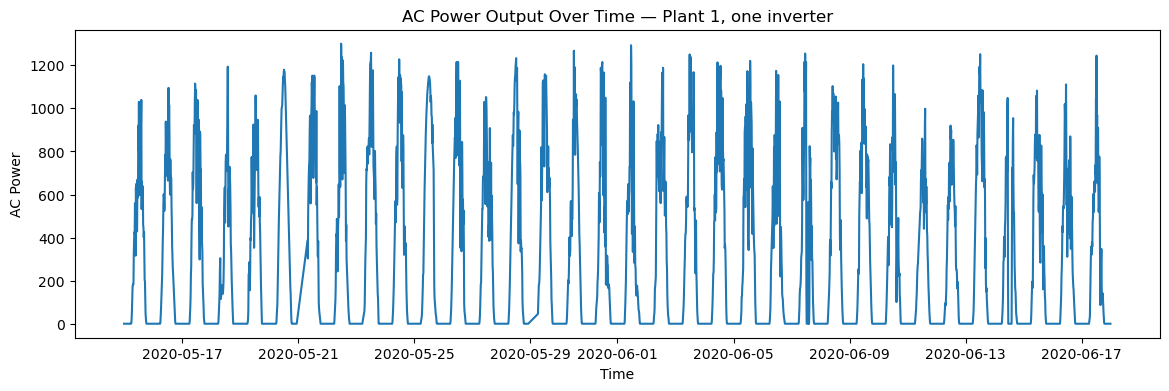

In [8]:
# Filter to one plant and one inverter (SOURCE_KEY) so the plot shows a single,
# clean time series rather than overlapping lines from ~22 inverters at once

sample = solar_df[(solar_df['PLANT'] == 'Plant_1') & (solar_df['SOURCE_KEY_gen'] == solar_df['SOURCE_KEY_gen'].iloc[0])]
plt.figure(figsize=(14, 4))
plt.plot(sample['DATE_TIME'], sample['AC_POWER'])
plt.title('AC Power Output Over Time — Plant 1, one inverter')
plt.xlabel('Time')
plt.ylabel('AC Power')
plt.show()